# Intent Classifier Graph Demo

This notebook demonstrates how to use the LangGraph-based intent classifier for SQL and chart requests in a chatbot application.

## Setup

First, let's import the necessary modules and set up our environment.

In [11]:
# !pip install --upgrade langchain_aws langchain_core langgraph
# ! pip install --quiet graphviz

In [12]:
import sys
import os
import json

# Install required packages with specific versions
#%pip install --quiet "langgraph>=0.0.21" "langchain>=0.1.4" "langchain-core>=0.1.17"

# Add the src directory to the Python path so we can import our modules
sys.path.append(os.path.abspath('../'))

# Import our intent classifier modules
from src.intent_classifier.classifier import IntentClassifierGraph
from src.intent_classifier.schema import (
    FirstQueryIntentType, 
    FollowupQueryIntentType,
    SalutationType
)
from src.intent_classifier.utils import format_context, context_to_string

## Setup AWS Credentials for Bedrock

For using Amazon Bedrock, you need to set up your AWS credentials. You can do this in several ways:

1. Using environment variables
2. Using AWS configuration files
3. Using AWS IAM roles

For this notebook, we'll use environment variables. Make sure to replace the placeholders with your actual AWS credentials.

In [13]:
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv(override=True)

print("AWS credentials loaded successfully")

AWS credentials loaded successfully


In [14]:
os.getenv("ANTHROPIC_MODEL_ID")

'us.anthropic.claude-3-5-sonnet-20241022-v2:0'

## Initialize the Intent Classifier Graph

Now, let's initialize our LangGraph-based intent classifier with Amazon Bedrock.

In [15]:
# Set AWS region
os.environ["AWS_DEFAULT_REGION"] = os.getenv("AWS_REGION_NAME")
# Initialize the classifier with the default Bedrock model
classifier = IntentClassifierGraph(model_id="anthropic.claude-3-sonnet-20240229-v1:0", temperature=0.1)

# If you want to use a different model, you can specify it
# classifier = IntentClassifierGraph(model_id="anthropic.claude-3-haiku-20240307-v1:0", temperature=0.1)

## Understanding the LangGraph Architecture

The `IntentClassifierGraph` uses LangGraph to build a state machine for intent classification. The workflow is:

1. First, check if the query is a salutation
2. If not a salutation, route based on whether it's a first query or follow-up
3. Classify the intent accordingly
4. Create the final intent object

Let's visualize this with a simple diagram:

```
                               ┌──────────────────┐
                               │                  │
                               │  check_salutation│
                               │                  │
                               └────────┬─────────┘
                                        │
                                        ▼
                                    ┌───────┐
                            No      │  Is   │      Yes
                        ┌───────────┤ Salut?├───────────┐
                        │           └───────┘           │
                        ▼                               ▼
           ┌─────────────────────┐                ┌────────────────┐
           │                     │                │                │
           │   route_query_type  │                │create_final_   │
           │                     │                │intent          │
           └───────────┬─────────┘                └────────────────┘
                       │                                  ▲
                       ▼                                  │
               ┌───────────────┐                          │
               │ Is First      │                          │
               │ Query?        │                          │
               └───┬───────────┘                          │
                   │                                      │
       ┌───────────┴───────────┐                          │
       │                       │                          │
       ▼                       ▼                          │
┌─────────────────┐    ┌─────────────────┐               │
│                 │    │                 │               │
│ classify_first_ │    │ classify_       │               │
│ query           │    │ followup_query  │               │
│                 │    │                 │               │
└────────┬────────┘    └────────┬────────┘               │
         │                      │                        │
         └──────────────────────┼────────────────────────┘
                                │
                                ▼
                      ┌─────────────────┐
                      │                 │
                      │      END        │
                      │                 │
                      └─────────────────┘
```

## Visualizing the LangGraph Structure with Graphviz

Now let's use the `visualize_graph` method to create a visual representation of the flow using Graphviz:

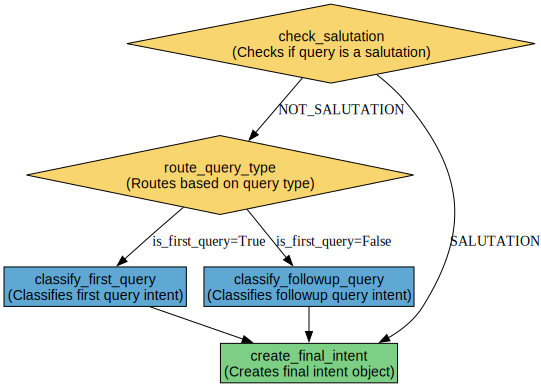

In [16]:
# Install graphviz if not already installed
# !pip install graphviz

# Make sure you have the system Graphviz package installed
# On MacOS: brew install graphviz
# On Ubuntu: apt-get install graphviz

# Generate and display the graph visualization
graph = classifier.visualize_graph(height=600, width=800)
graph

The visualization above shows the complete flow of our LangGraph classifier:

- **Diamond nodes** (yellow) represent decision points that route the flow based on conditions
- **Box nodes** (blue) represent processing steps that perform classification
- **Box nodes** (green) represent output nodes that produce the final result

The edges show the possible paths through the graph, with labels indicating the conditions for each path.

This type of visualization is very helpful for understanding and debugging the LangGraph implementation.

## Test Classification Using the LangGraph Flow

Let's test the classifier with some example queries, using its main `classify_query` method which runs the full graph:

In [17]:
# Test with various types of inputs
test_inputs = [
    {"query": "Hello there!", "type": "Salutation (Greeting)"},
    {"query": "Show me sales data for all regions", "type": "First Query"},
    {"query": "Thanks for the help", "type": "Salutation (Thanks)"},
    {"query": "Change the chart to a pie chart", "type": "Follow-up Query"},
    {"query": "Goodbye", "type": "Salutation (Goodbye)"}
]

for test in test_inputs:
    query = test["query"]
    expected_type = test["type"]
    
    print(f"\n===== Testing: {expected_type} =====")
    print(f"Input: '{query}'")
    
    # For follow-up queries, we need to provide context
    if expected_type == "Follow-up Query":
        # Create some example context
        context = {
            "previous_sql": "SELECT region, SUM(sales) as total_sales FROM sales_data GROUP BY region",
            "previous_chart_config": {"type": "bar", "x_axis": "region", "y_axis": "total_sales"}
        }
        # Create initial state for the graph
        initial_state = {
            "query": query,
            "is_first_query": False,
            "context": context,
            "salutation_type": None,
            "first_query_type": None,
            "followup_query_type": None,
            "final_intent": None
        }
    else:
        # Create initial state for the graph
        initial_state = {
            "query": query,
            "is_first_query": True,
            "context": None,
            "salutation_type": None,
            "first_query_type": None,
            "followup_query_type": None,
            "final_intent": None
        }
    
    # Invoke the graph with the initial state
    result = classifier.graph.invoke(initial_state,config={"configurable": {"thread_id": 42}})
    # Get the final intent from the result
    result = result.get("final_intent")

    print("\n===== Result =====")
    print(f"Result: '{result}'")
    
    print("\nResult:")
    print(f"  Intent Type: {result.intent_type if result else 'None'}")
    print(f"  Raw Query: {result.raw_query if result else 'None'}")
    
    if hasattr(result, 'is_salutation') and result.is_salutation:
        print(f"  Is Salutation: {result.is_salutation}")
    elif hasattr(result, 'is_first_query'):
        print(f"  Is First Query: {result.is_first_query}")
        if hasattr(result, 'context') and result.context:
            print(f"  Has Context: {bool(result.context)}")


===== Testing: Salutation (Greeting) =====
Input: 'Hello there!'

===== Result =====
Result: 'None'

Result:
  Intent Type: None
  Raw Query: None

===== Testing: First Query =====
Input: 'Show me sales data for all regions'

===== Result =====
Result: 'None'

Result:
  Intent Type: None
  Raw Query: None

===== Testing: Salutation (Thanks) =====
Input: 'Thanks for the help'

===== Result =====
Result: 'None'

Result:
  Intent Type: None
  Raw Query: None

===== Testing: Follow-up Query =====
Input: 'Change the chart to a pie chart'

===== Result =====
Result: 'None'

Result:
  Intent Type: None
  Raw Query: None

===== Testing: Salutation (Goodbye) =====
Input: 'Goodbye'

===== Result =====
Result: 'None'

Result:
  Intent Type: None
  Raw Query: None


## Exploring the State Flow

Let's examine how the state flows through the LangGraph. We can trace the execution by examining the intermediate states:

In [18]:
def trace_classification(query, is_first_query=True, context=None):
    """Trace the classification through the LangGraph by running nodes manually."""
    # Initial state
    state = {
        "query": query,
        "is_first_query": is_first_query,
        "context": context,
        "salutation_type": None,
        "first_query_type": None,
        "followup_query_type": None,
        "final_intent": None
    }
    
    print(f"\n===== Tracing classification for: '{query}' =====")
    print("\nInitial State:")
    print_state(state)
    
    # Run the actual graph
    final_state = classifier.graph.invoke(state,config={"configurable": {"thread_id": 42}})
    
    print("\nFinal State:")
    print_state(final_state)
    
    print("\nFinal Intent:")
    print(final_state["final_intent"])
    
    return final_state

def print_state(state):
    """Print the current state in a readable format."""
    for key, value in state.items():
        if key == "context" and value:
            print(f"  {key}: {type(value).__name__} (present)")
        elif key == "final_intent" and value:
            print(f"  {key}: {type(value).__name__} (present)")
        else:
            print(f"  {key}: {value}")

# Test with different types of queries
trace_classification("Hello there!")  # Salutation
trace_classification("Show me sales by region")  # First query

# Create context for followup query
context = {
    "previous_sql": "SELECT region, SUM(sales) as total_sales FROM sales_data GROUP BY region",
    "previous_chart_config": {"type": "bar", "x_axis": "region", "y_axis": "total_sales"}
}
trace_classification("Change to a pie chart", is_first_query=False, context=context)  # Followup query


===== Tracing classification for: 'Hello there!' =====

Initial State:
  query: Hello there!
  is_first_query: True
  context: None
  salutation_type: None
  first_query_type: None
  followup_query_type: None
  final_intent: None

Final State:
  query: Hello there!
  is_first_query: True
  context: None
  salutation_type: None
  first_query_type: None
  followup_query_type: None
  final_intent: None

Final Intent:
None

===== Tracing classification for: 'Show me sales by region' =====

Initial State:
  query: Show me sales by region
  is_first_query: True
  context: None
  salutation_type: None
  first_query_type: None
  followup_query_type: None
  final_intent: None

Final State:
  query: Show me sales by region
  is_first_query: True
  context: None
  salutation_type: None
  first_query_type: None
  followup_query_type: None
  final_intent: None

Final Intent:
None

===== Tracing classification for: 'Change to a pie chart' =====

Initial State:
  query: Change to a pie chart
  is_fi

{'query': 'Change to a pie chart',
 'is_first_query': False,
 'context': {'previous_sql': 'SELECT region, SUM(sales) as total_sales FROM sales_data GROUP BY region',
  'previous_chart_config': {'type': 'bar',
   'x_axis': 'region',
   'y_axis': 'total_sales'}},
 'salutation_type': None,
 'first_query_type': None,
 'followup_query_type': None,
 'final_intent': None}

## Testing First Query Classification

Let's test a variety of first queries to see how they're classified:

In [10]:
# Example first queries
first_queries = [
    "Show me the total sales by region",
    "Get me a breakdown of revenue by product category and create a bar chart",
    "Write a SQL query to find all customers who haven't ordered in the last 6 months",
    "Create a query to analyze monthly sales trends and visualize it as a line chart",
    "I want to see customer retention rates",
    "Generate a visualization of our quarterly performance"
]

# Classify each query
print("\n===== First Query Classification =====\n")
for query in first_queries:
    intent = classifier.classify_query(query, is_first_query=True)
    print(f"Query: '{query}'")
    print(f"Intent Type: {intent.intent_type}\n")


===== First Query Classification =====



AttributeError: 'IntentClassifierGraph' object has no attribute 'classify_query'

## Testing Follow-up Query Classification

Now let's test follow-up queries with context:

In [ ]:
# Create example context
previous_sql = """
SELECT region, SUM(sales) as total_sales
FROM sales_data
GROUP BY region
ORDER BY total_sales DESC
"""

previous_chart_config = {
    "type": "bar",
    "x_axis": "region",
    "y_axis": "total_sales",
    "title": "Total Sales by Region",
    "color": "blue"
}

# Format the context
context = format_context(
    previous_sql=previous_sql,
    previous_chart_config=previous_chart_config,
    previous_intents=[{"raw_query": "Get me sales by region", "intent_type": "sql_and_chart"}]
)

# Example follow-up queries
followup_queries = [
    "Add a filter for the year 2024",
    "Change the chart type to pie chart",
    "Include product category in the query and update the chart to show a stacked bar chart",
    "Make the bars red",
    "Sort by sales in ascending order",
    "Show only the top 5 regions"
]

# Classify each follow-up query
print("\n===== Follow-up Query Classification =====\n")
for query in followup_queries:
    intent = classifier.classify_query(query, is_first_query=False, context=context)
    print(f"Query: '{query}'")
    print(f"Intent Type: {intent.intent_type}\n")

## Testing Salutation Detection

Let's test the classifier's ability to detect different types of salutations:

In [ ]:
# Example salutation messages
salutation_messages = [
    "Hi there!",                      # Greeting
    "Hello, how are you today?",      # Greeting
    "Thanks for your help!",          # Thanks
    "Thank you for the assistance",   # Thanks
    "Goodbye, talk to you later",     # Goodbye
    "See you tomorrow",               # Goodbye
    "I appreciate your work",         # Thanks/Other
    "Show me sales data for 2024"     # Not a salutation (actual query)
]

# Classify each message
print("\n===== Salutation Detection =====\n")
for message in salutation_messages:
    intent = classifier.classify_query(message)
    
    print(f"Message: '{message}'")
    if hasattr(intent, 'is_salutation') and intent.is_salutation:
        print(f"Detected as salutation - Type: {intent.intent_type}\n")
    else:
        print(f"Not detected as a salutation - Type: {intent.intent_type}\n")

## Simulating a Complete Conversation

Let's simulate a complete conversation flow using the `IntentClassifierGraph`:

In [ ]:
def simulate_conversation():
    # Conversation state
    current_sql = None
    current_chart_config = None
    conversation_context = None
    previous_intents = []
    is_first_query = True
    
    # Simulated conversation
    messages = [
        "Hello!",                                                  # Greeting
        "Show me total sales by product category as a bar chart",  # First query
        "Add a filter for transactions after January 2024",        # Follow-up
        "Thanks for that!",                                        # Thanks
        "Change the chart to a pie chart",                         # Follow-up
        "Group by region instead of product category",             # Follow-up
        "That's all for now, goodbye"                              # Goodbye
    ]
    
    for i, message in enumerate(messages):
        print(f"\n===== Message {i+1} =====")
        print(f"User: {message}")
        
        # Classify the intent
        intent = classifier.classify_query(
            query=message,
            is_first_query=is_first_query,
            context=conversation_context
        )
        
        print(f"Detected Intent: {intent.intent_type}")
        
        # Handle the intent based on its type
        if hasattr(intent, 'is_salutation') and intent.is_salutation:
            if intent.intent_type == SalutationType.GREETING:
                print("System: Hello! How can I help you with SQL queries or visualizations today?")
            elif intent.intent_type == SalutationType.THANKS:
                print("System: You're welcome! Is there anything else you'd like to know or modify?")
            elif intent.intent_type == SalutationType.GOODBYE:
                print("System: Goodbye! Feel free to come back if you need more assistance.")
            else:
                print("System: I'm here to help with your SQL and visualization needs.")
        elif is_first_query and intent.intent_type == FirstQueryIntentType.SQL_AND_CHART:
            # Handle first query for SQL and chart
            print("System: Generating SQL query and chart...")
            current_sql = """
            SELECT product_category, SUM(sales) as total_sales
            FROM sales_data
            GROUP BY product_category
            ORDER BY total_sales DESC
            """
            current_chart_config = {
                "type": "bar",
                "x_axis": "product_category",
                "y_axis": "total_sales",
                "title": "Total Sales by Product Category"
            }
            print(f"Generated SQL:\n{current_sql}")
            print(f"Generated Chart Config:\n{json.dumps(current_chart_config, indent=2)}")
            is_first_query = False
        elif not is_first_query:
            if intent.intent_type == FollowupQueryIntentType.MODIFY_CHART_ONLY:
                # Handle chart modification
                print("System: Modifying chart configuration...")
                if "pie chart" in message.lower():
                    current_chart_config["type"] = "pie"
                print(f"Modified Chart Config:\n{json.dumps(current_chart_config, indent=2)}")
            elif intent.intent_type == FollowupQueryIntentType.MODIFY_SQL_AND_CHART:
                # Handle SQL and chart modification
                print("System: Modifying both SQL query and chart...")
                if "January 2024" in message:
                    current_sql = current_sql.replace(
                        "FROM sales_data",
                        "FROM sales_data\nWHERE transaction_date >= '2024-01-01'"
                    )
                elif "region" in message:
                    current_sql = """
                    SELECT region, SUM(sales) as total_sales
                    FROM sales_data
                    WHERE transaction_date >= '2024-01-01'
                    GROUP BY region
                    ORDER BY total_sales DESC
                    """
                    current_chart_config["x_axis"] = "region"
                    current_chart_config["title"] = "Total Sales by Region"
                
                print(f"Modified SQL:\n{current_sql}")
                print(f"Modified Chart Config:\n{json.dumps(current_chart_config, indent=2)}")
        
        # Update conversation context for next iteration
        if not hasattr(intent, 'is_salutation'):
            previous_intents.append({
                "raw_query": message,
                "intent_type": str(intent.intent_type)
            })
            
            conversation_context = format_context(
                previous_sql=current_sql,
                previous_chart_config=current_chart_config,
                previous_intents=previous_intents
            )
    
    print("\n===== Conversation Completed =====")

# Run the simulated conversation
simulate_conversation()

## Handling Misclassification and Edge Cases

Let's see how the classifier handles some edge cases and potential misclassifications:

In [ ]:
# Edge cases and ambiguous queries
edge_cases = [
    "hello show me sales data",            # Mixed salutation and query
    "thanks can you make it a pie chart",  # Mixed thanks and followup
    "the data looks wrong",                # Feedback but not a clear intent
    "what about monthly trends?",          # Ambiguous followup
    "could you make the bars blue?",       # Chart formatting only
    ""                                     # Empty message
]

# Create a context for testing followups
context = {
    "previous_sql": "SELECT product, SUM(sales) FROM sales GROUP BY product",
    "previous_chart_config": {"type": "bar"}
}

print("\n===== Testing Edge Cases =====\n")
for case in edge_cases:
    if not case:  # Handle empty message separately
        print(f"Message: '<empty>'")
    else:
        print(f"Message: '{case}'")
    
    try:
        # Try as potential salutation
        intent = classifier.classify_query(case)
        print(f"Classification result: {intent.intent_type}")
        
        # If not detected as a salutation, try as followup
        if not hasattr(intent, 'is_salutation'):
            followup_intent = classifier.classify_query(case, is_first_query=False, context=context)
            print(f"Followup classification: {followup_intent.intent_type}")
    except Exception as e:
        print(f"Error classifying: {str(e)}")
    
    print()

## Integration with a Real-world Application

Here's a pseudo-code example of how to integrate the `IntentClassifierGraph` in a real-world chatbot application:

In [ ]:
def process_user_message(message, conversation_state):
    """Process a user message in a chatbot context using the LangGraph classifier.
    
    Args:
        message: The user's message text
        conversation_state: Dictionary tracking the state of the conversation
        
    Returns:
        Updated conversation state and response to the user
    """
    # Extract current state
    is_first_query = conversation_state.get("is_first_query", True)
    current_sql = conversation_state.get("current_sql")
    current_chart_config = conversation_state.get("current_chart_config")
    previous_intents = conversation_state.get("previous_intents", [])
    
    # Format context
    context = None
    if not is_first_query:
        context = format_context(
            previous_sql=current_sql,
            previous_chart_config=current_chart_config,
            previous_intents=previous_intents
        )
    
    # Initialize the intent classifier
    classifier = IntentClassifierGraph()
    
    # Classify the intent
    intent = classifier.classify_query(
        query=message,
        is_first_query=is_first_query,
        context=context
    )
    
    # Handle the intent based on its type
    if hasattr(intent, 'is_salutation') and intent.is_salutation:
        # Handle salutations
        if intent.intent_type == SalutationType.GREETING:
            response = "Hello! How can I help you with SQL queries or visualizations today?"
        elif intent.intent_type == SalutationType.THANKS:
            response = "You're welcome! Is there anything else you'd like to know or visualize?"
        elif intent.intent_type == SalutationType.GOODBYE:
            response = "Goodbye! Feel free to come back if you need more assistance."
        else:  # OTHER
            response = "I'm here to help with your SQL and visualization needs."
            
    elif intent.intent_type == FirstQueryIntentType.SQL_ONLY:
        # Generate SQL only
        current_sql = generate_sql(message)  # Placeholder for SQL generation
        sql_results = execute_sql(current_sql)  # Placeholder for SQL execution
        response = format_sql_results(sql_results)  # Placeholder for formatting
        is_first_query = False
        
    elif intent.intent_type == FirstQueryIntentType.SQL_AND_CHART:
        # Generate SQL and chart
        current_sql = generate_sql(message)  # Placeholder
        sql_results = execute_sql(current_sql)  # Placeholder
        current_chart_config = generate_chart_config(message, sql_results)  # Placeholder
        chart_image = render_chart(sql_results, current_chart_config)  # Placeholder
        response = format_sql_and_chart_results(sql_results, chart_image)  # Placeholder
        is_first_query = False
        
    elif intent.intent_type == FollowupQueryIntentType.MODIFY_CHART_ONLY:
        # Modify chart only
        sql_results = execute_sql(current_sql)  # Placeholder
        current_chart_config = modify_chart_config(current_chart_config, message)  # Placeholder
        chart_image = render_chart(sql_results, current_chart_config)  # Placeholder
        response = format_chart_results(chart_image)  # Placeholder
        
    elif intent.intent_type == FollowupQueryIntentType.MODIFY_SQL_AND_CHART:
        # Modify both SQL and chart
        current_sql = modify_sql(current_sql, message, context)  # Placeholder
        sql_results = execute_sql(current_sql)  # Placeholder
        current_chart_config = modify_chart_config(current_chart_config, message)  # Placeholder
        chart_image = render_chart(sql_results, current_chart_config)  # Placeholder
        response = format_sql_and_chart_results(sql_results, chart_image)  # Placeholder
    
    # Update the previous intents for context
    if not hasattr(intent, 'is_salutation'):
        previous_intents.append({
            "raw_query": message,
            "intent_type": str(intent.intent_type)
        })
    
    # Update conversation state
    conversation_state.update({
        "is_first_query": is_first_query,
        "current_sql": current_sql,
        "current_chart_config": current_chart_config,
        "previous_intents": previous_intents
    })
    
    return conversation_state, response

# Placeholder functions (these would be implemented in a real app)
def generate_sql(query):
    return "SELECT * FROM sample_table"

def execute_sql(sql):
    return [{"sample": "data"}]

def generate_chart_config(query, data):
    return {"type": "bar"}

def modify_sql(current_sql, query, context):
    return current_sql + "\nWHERE sample_condition = true"

def modify_chart_config(config, query):
    config["type"] = "pie" if "pie" in query.lower() else config["type"]
    return config

def render_chart(data, config):
    return "chart.png"

def format_sql_results(results):
    return "Here are your SQL results."

def format_chart_results(chart):
    return "Here is your chart."

def format_sql_and_chart_results(results, chart):
    return "Here are your SQL results and chart."

## Performance Considerations

When using the `IntentClassifierGraph` in a production environment, there are several performance considerations to keep in mind:

## Handling the InvalidUpdateError Issue

LangGraph throws an `InvalidUpdateError` with the message "Can receive only one value per step" when multiple nodes try to update the same state key concurrently. This is a common issue in LangGraph workflows. Let's fix it by understanding how to properly annotate keys that may receive multiple values:

In [ ]:
from typing import Annotated, TypedDict
from typing_extensions import Annotated
from langgraph.graph import StateGraph

# Example of how to fix the InvalidUpdateError by using Annotated types
class FixedIntentClassifierState(TypedDict):
    """Fixed state definition that avoids the InvalidUpdateError."""
    # Keys that may be updated by multiple nodes should use Annotated[type, "merge"]
    # This tells LangGraph how to handle concurrent updates to these keys
    query: str  # This field only gets set once, so no annotation needed
    is_first_query: bool  # This field only gets set once, so no annotation needed
    context: dict  # This field only gets set once in our flow
    # These fields might be updated by multiple nodes in parallel paths
    salutation_type: Annotated[str, "override"]  # Use "override" when you want the latest value
    first_query_type: Annotated[str, "override"]  # Use "override" to take the latest update
    followup_query_type: Annotated[str, "override"]  # Use "override" to take the latest update
    final_intent: Annotated[object, "override"]  # Use "override" for object updates

# Example of how to update the graph builder with this fixed state type
def create_fixed_intent_classifier():
    """Create a version of the intent classifier that avoids the InvalidUpdateError."""
    from langchain_aws import ChatBedrock
    
    # Create the classifier component
    llm = ChatBedrock(model_id="anthropic.claude-3-sonnet-20240229-v1:0", temperature=0.0)
    
    # Use the fixed state definition
    builder = StateGraph(FixedIntentClassifierState)
    
    # The rest of the graph creation would be the same,
    # but now using the annotated state keys
    # ...
    
    return builder

# Code to implement in the actual classifier.py file to fix the issue
"""Example fix for classifier.py - demonstration only
from typing import Dict, Any, Optional, Union, TypedDict, Annotated
from typing_extensions import Annotated

class IntentClassifierState(TypedDict):
    """State for the intent classifier graph."""
    query: str
    is_first_query: bool
    context: Optional[Dict[str, Any]]
    salutation_type: Annotated[Optional[str], "override"]  # <- Add this annotation
    first_query_type: Annotated[Optional[str], "override"]  # <- Add this annotation
    followup_query_type: Annotated[Optional[str], "override"]  # <- Add this annotation
    final_intent: Annotated[Optional[Union[FirstQueryIntent, FollowupQueryIntent, SalutationIntent, None]], "override"]  # <- Add this annotation
"""

### Key Points About Fixing the InvalidUpdateError:

1. **Root Cause**: This error occurs when two or more parallel execution paths in a LangGraph attempt to update the same key in the state dictionary. LangGraph doesn't know how to resolve these conflicts by default.

2. **Solution Options**:
   - Use `Annotated[Type, "override"]` when you want the latest value to win
   - Use `Annotated[Type, "merge"]` when you want to merge values (works for lists/dicts)
   - Use `Annotated[Type, "reduce"]` with a custom reducer function for complex merging logic

3. **Usage in our Graph**: For the intent classifier, we should use "override" for most fields since we want the latest classification to take precedence.

4. **Application Architecture**: This error most commonly appears in more complex LangGraph implementations with concurrent execution paths or when multiple threads/clients try to update the same graph state.

In [ ]:
# Actual implementation fix for the classifier
# Note: This code should be applied to the actual classifier.py file

def fix_intent_classifier_state():
    """Function to show what changes need to be made to the actual classifier file."""
    # The code below is a demonstration of what the fix should look like in the actual file
    print("To fix the InvalidUpdateError, update your IntentClassifierState class with Annotated types:")
    print("""
    # In classifier.py file:
    from typing import Dict, Any, Optional, Union, TypedDict, Annotated
    # or if using Python < 3.9:
    # from typing import Dict, Any, Optional, Union, TypedDict
    # from typing_extensions import Annotated
    
    class IntentClassifierState(TypedDict):
        """State for the intent classifier graph."""
        query: str
        is_first_query: bool
        context: Optional[Dict[str, Any]]
        salutation_type: Annotated[Optional[str], "override"]
        first_query_type: Annotated[Optional[str], "override"]
        followup_query_type: Annotated[Optional[str], "override"]
        final_intent: Annotated[Optional[Union[FirstQueryIntent, FollowupQueryIntent, SalutationIntent, None]], "override"]
    """)
    
# Show the implementation fix
fix_intent_classifier_state()

1. **LLM API Calls**: The `IntentClassifierGraph` makes at least one LLM API call per classification, and potentially more depending on the path through the graph. Each API call adds latency and cost.

2. **Caching**: Consider implementing caching for common queries or salutations to reduce API calls.

3. **Concurrent Processing**: In a production environment with many users, you might need to handle multiple classification requests concurrently.

4. **Model Selection**: The choice of model has significant impact on both performance and accuracy. Smaller models like Claude Haiku might be faster but potentially less accurate than larger models like Claude Sonnet.

5. **State Management**: The graph maintains state through the classification process, which needs to be properly managed in a production environment.

6. **Error Handling**: Robust error handling is critical for production use to handle LLM API failures or unexpected inputs.

## Custom Checkpoint Implementation

The `IntentClassifierGraph` uses `LocalStateCheckpoint` for state management, which stores state locally. In a production environment, you might want to use a distributed checkpoint to share state across multiple instances:

In [ ]:
# Example of how to implement a custom checkpoint for the graph
# This is pseudocode and would need to be adapted for your specific environment

from langgraph.checkpoint import Checkpoint

class RedisCheckpoint(Checkpoint):
    """Example custom checkpoint implementation using Redis."""
    
    def __init__(self, redis_client):
        self.client = redis_client
        
    async def get(self, thread_id: str):
        """Get state from Redis."""
        state_json = self.client.get(f"state:{thread_id}")
        if state_json:
            return json.loads(state_json)
        return None
    
    async def put(self, thread_id: str, state: dict):
        """Store state in Redis."""
        self.client.set(f"state:{thread_id}", json.dumps(state))
        
    async def list(self):
        """List all thread IDs."""
        keys = self.client.keys("state:*")
        return [key.replace("state:", "") for key in keys]
        
    async def delete(self, thread_id: str):
        """Delete state for a thread."""
        self.client.delete(f"state:{thread_id}")

# Example of how to use a custom checkpoint with the graph
def create_classifier_with_custom_checkpoint(redis_url):
    """Create a classifier with a custom Redis-based checkpoint."""
    import redis
    
    # Connect to Redis
    redis_client = redis.Redis.from_url(redis_url)
    
    # Create custom checkpoint
    checkpoint = RedisCheckpoint(redis_client)
    
    # Create the classifier components
    llm = ChatBedrock(model_id="anthropic.claude-3-sonnet-20240229-v1:0")
    
    # Create the graph
    builder = StateGraph(IntentClassifierState)
    
    # Add nodes (simplified for example)
    # ...
    
    # Compile with custom checkpoint
    graph = builder.compile(checkpointer=checkpoint)
    
    return graph

## Conclusion

In this notebook, we've explored the `IntentClassifierGraph` implementation for classifying user intents in SQL and visualization queries. The LangGraph-based approach provides several advantages:

1. **Flexible Flow Control**: The graph structure allows for conditional routing of classification based on the query type.

2. **State Management**: The state is maintained throughout the classification process, allowing for rich context.

3. **Modular Design**: Each node in the graph has a specific responsibility, making the code more maintainable.

4. **Context Awareness**: The classifier can use context from previous interactions to better understand follow-up queries.

5. **Comprehensive Intent Types**: The system can classify a wide range of intents, from salutations to specific SQL and chart modification requests.

This implementation serves as a solid foundation for a natural language interface to SQL and data visualization systems, enabling users to interact with their data through simple, conversational commands.